### **Realistic Case: Task 1**:
In this task we attempt to extract the license plate characters using the functions from the ideal case and evaluate whether character recognition is successful without any deblurring.\
Since the algorithms do not account for the blur in the images, the answer is likely negative.

In [15]:
from PIL import Image
from PIL import ImageOps
import numpy as np
import os
import matplotlib.pyplot as plt

In [16]:
# First, the same segmentation function:
def character_splitter (img, image_name, slicing_points, loading_needed=True, output_directory = 'real_slices', save_slices = False, print_slices = False):
    if(loading_needed):
        img = Image.open(img)

    width, height = img.size

    sliced_images = []
    for i, (start_x, end_x, start_y, end_y) in enumerate(slicing_points):
        # Clamp coordinates to image bounds
        left = max(0, min(start_x, width))
        right = max(0, min(end_x, width))

        up = max(0, min(start_y, height))
        down = max(0, min(end_y, height))
        
        # Ensure left < right
        if left >= right:
            continue  # Skip invalid regions
        # The same for the vertical bounds
        if up >= down:
            continue
        
        crop_box = (left, up, right, down)
        sliced_img = img.crop(crop_box)
        sliced_images.append(sliced_img)

        if save_slices:
            if not os.path.exists(output_directory):
                os.makedirs(output_directory)
            filename = f"{output_directory}/{image_name}_slice_{i}.png"
            sliced_img.save(filename)

        if print_slices:
            print(f"Slice {i} ({left}px to {right}px):")
            display(sliced_img)
            
    return sliced_images

Slice 0 (132px to 205px):


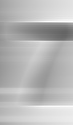

Slice 1 (203px to 278px):


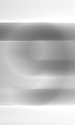

Slice 2 (310px to 393px):


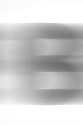

Slice 3 (420px to 487px):


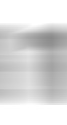

Slice 4 (483px to 559px):


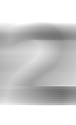

Slice 5 (553px to 630px):


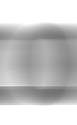

Slice 6 (625px to 705px):


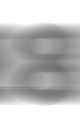

[<PIL.Image.Image image mode=L size=75x125>,
 <PIL.Image.Image image mode=L size=77x125>,
 <PIL.Image.Image image mode=L size=100x125>,
 <PIL.Image.Image image mode=L size=85x125>,
 <PIL.Image.Image image mode=L size=78x125>,
 <PIL.Image.Image image mode=L size=75x125>,
 <PIL.Image.Image image mode=L size=76x125>]

In [17]:
# Now we test the segmantation function, save all the outputs and show one of the result sets as an example

character_splitter('real1.jpg', 'real1', [[132, 205, 25, 150], [205, 280, 25, 150], [310, 390, 25, 150], [420, 490, 25, 150], [488, 567, 25, 150], [563, 642, 25, 150], [640, 710, 25, 150]], save_slices=True)
character_splitter('real2.jpg', 'real2', [[130, 200, 25, 150], [200, 277, 25, 150], [300, 400, 25, 150], [420, 502, 25, 150], [496, 577, 25, 150], [572, 647, 25, 150], [643, 717, 25, 150]], save_slices=True)
character_splitter('real3.jpg', 'real3', [[132, 205, 25, 150], [203, 278, 25, 150], [310, 393, 25, 150], [420, 487, 25, 150], [483, 559, 25, 150], [553, 630, 25, 150], [625, 705, 25, 150]], save_slices=True, print_slices=True)
character_splitter('real4.jpg', 'real4', [[125, 200, 25, 150], [197, 274, 25, 150], [300, 400, 25, 150], [420, 505, 25, 150], [499, 577, 25, 150], [572, 647, 25, 150], [643, 719, 25, 150]], save_slices=True)


In [18]:
# The image padder function later used to unify the dimensions of the slices and the reference character images

def pad_images_to_match_size(img1, img2, fill=255):
    # Pads the smaller image (in width and height) so that both images have the same dimensions.
    # Padding is done symmetrically (equal on both sides).
    # fill is the padding color

    # converting both to grayscale if needed
    img1 = img1.convert('L')
    img2 = img2.convert('L')

    w1, h1 = img1.size
    w2, h2 = img2.size

    target_width = max(w1, w2)
    target_height = max(h1, h2)

    def pad_to_size(img, target_w, target_h):
        w, h = img.size
        pad_w = (target_w - w)
        pad_h = (target_h - h)
        padding = (
            pad_w // 2,           # left
            pad_h // 2,           # top
            pad_w - pad_w // 2,   # right
            pad_h - pad_h // 2    # bottom
        )
        return ImageOps.expand(img, padding, fill=fill)

    return pad_to_size(img1, target_width, target_height), pad_to_size(img2, target_width, target_height)


In [19]:
# Now the function of adapted 1D correlation to match the samples with the references
def image_correlation_1D(slice_img, template_img):
    # Convert both to grayscale
    slice_gray = slice_img.convert('L')
    template_gray = template_img.convert('L')

    # # Resize template to match height of slice (preserving aspect ratio roughly)
    # template_gray = template_gray.resize(slice_gray.size)

    # After writing the line above, we tested and realized that the algorithm does not have enough precision. For example it mistakes 5 for 6, B for 0 and D for 0.
    # One reason is that when resizing, the image ratio changes. So, we decided to pad the  smaller image with white instead.
    padded_slice, padded_template = pad_images_to_match_size(slice_gray, template_gray)

    # Flatten to 1D float arrays
    f = np.asarray(padded_slice,   dtype=np.float32).ravel()
    t = np.asarray(padded_template, dtype=np.float32).ravel()

    # Now normalizing the arrays. Normalization means subtracting the data (centering around 0) and dividing by the standard deviation (scaling to unit variance).
    # first, zero-centering:
    f_mean, t_mean = f.mean(), t.mean()
    f_centered = f - f_mean
    t_centered = t - t_mean

    # Compute denominator (avoiding zero‐division)
    f_norm = np.linalg.norm(f_centered)
    t_norm = np.linalg.norm(t_centered)
    eps = 1e-8
    if f_norm < eps or t_norm < eps:
        return -1.0

    # Correlation Coefficient
    correlation_coeff = (f_centered @ t_centered) / (f_norm * t_norm)
    return correlation_coeff

In [20]:
# Loading the template characters
def char_load():
    templates = {}
    for digit in range(10):
        path = f"numbers/{digit}.jpg"
        templates[str(digit)] = Image.open(path)

    templates[10] = Image.open("letters/A.jpg")
    templates[11] = Image.open("letters/B.jpg")
    templates[12] = Image.open("letters/C.jpg")
    templates[13] = Image.open("letters/D.jpg")

    return templates

In [21]:
# Now putting them all together in a function to form the whole algorithm
def LPR(image_number, slices, templates, downsampled=False, factor=None):
    license_number = ""
    best_correlation_scores = []
    # slices is a list
    for i, slc_img in enumerate(slices):
        best_digit = None
        best_score = -np.inf
        
        # templates is a dictionary
        for digit, tmpl_img in templates.items():
            score = image_correlation_1D(slc_img, tmpl_img)

            # if(downsampled == False): # since in the downsampling part the number of times we call this function is a lot and the output n=box gets messy
            #    print(f"Image{image_number}, Digit{i}, Template {digit} → correlation: {score:.3f}")
            
            if score >  best_score:
                best_score = score
                best_digit = digit

        if(best_digit == 10):
            license_number += " A "
        elif(best_digit == 11):
            license_number += " B "
        elif(best_digit == 12):
            license_number += " C "
        elif(best_digit == 13):
            license_number += " D "
        else:
            license_number += str(best_digit)
        best_correlation_scores.append(best_score)
        
    print()
    if(downsampled):
        print(f"Image Number {image_number}, downsample by: {factor}")
    else:
        print(f"Image Number {image_number}, image not downsampled")
    print(f"     Recognized license plate: {license_number}")
    print("     Best correlation scores in order are: ", best_correlation_scores)
    print()
    print()
    return license_number, best_correlation_scores

In [22]:
# Running this for all given plate images
templates = char_load()
Expected_License_Plates = ["98 C 7445", "56 A 7495", "79 B 1208", "93 D 4328"]

# a function that returns a list of loaded PIL Image objects, given a list of file paths
def load_slices_from_paths(image_paths):
    return [Image.open(path) for path in image_paths]


# IMAGE 1:
ideal1_slices_image_paths = []
for i in range(7):
    path = f"real_slices/real1_slice_{i}.png"
    ideal1_slices_image_paths.append(path)

LPR('1', load_slices_from_paths(ideal1_slices_image_paths), templates)
print("     Expected LP: ", Expected_License_Plates[0])

# IMAGE 2:
ideal2_slices_image_paths = []
for i in range(7):
    path = f"real_slices/real2_slice_{i}.png"
    ideal2_slices_image_paths.append(path)

LPR('2', load_slices_from_paths(ideal2_slices_image_paths), templates)
print("     Expected LP: ", Expected_License_Plates[1])

# IMAGE 3:
ideal3_slices_image_paths = []
for i in range(7):
    path = f"real_slices/real3_slice_{i}.png"
    ideal3_slices_image_paths.append(path)

LPR('3', load_slices_from_paths(ideal3_slices_image_paths), templates)
print("     Expected LP: ", Expected_License_Plates[2])

# IMAGE 4:
ideal4_slices_image_paths = []
for i in range(7):
    path = f"real_slices/real4_slice_{i}.png"
    ideal4_slices_image_paths.append(path)

LPR('4', load_slices_from_paths(ideal4_slices_image_paths), templates)
print("     Expected LP: ", Expected_License_Plates[3])


Image Number 1, image not downsampled
     Recognized license plate:  B  B  A  B  D  A  B 
     Best correlation scores in order are:  [np.float32(0.6429187), np.float32(0.7195956), np.float32(0.62400556), np.float32(0.6317947), np.float32(0.636089), np.float32(0.6348238), np.float32(0.7375266)]


     Expected LP:  98 C 7445

Image Number 2, image not downsampled
     Recognized license plate:  A  A 311 A  A 
     Best correlation scores in order are:  [np.float32(0.28880537), np.float32(0.27310005), np.float32(0.32646912), np.float32(0.3847194), np.float32(0.40984446), np.float32(0.32911372), np.float32(0.263117)]


     Expected LP:  56 A 7495

Image Number 3, image not downsampled
     Recognized license plate:  B  B  A  B  D  D  B 
     Best correlation scores in order are:  [np.float32(0.5946723), np.float32(0.67087656), np.float32(0.5751126), np.float32(0.6934618), np.float32(0.6504732), np.float32(0.67816705), np.float32(0.66844696)]


     Expected LP:  79 B 1208

Image Numbe

As we see from the outputs reported, the correlation values are low and the recognized license numbers are far different from the ones expected. This clearly shows that proper LPR would not be possible without deblurring.